In [1]:
import pandas as pd
from pathlib import Path
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
import random
import numpy as np

def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✅ Random seed set to {seed}")


set_seed(42)  


label_path  = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\scientificProject\data\labels.csv"
label_df = pd.read_csv(label_path)
label_df["name"] = label_df["name"].astype(str)
label = {}
for item in range(len(label_df['name'])):
    label[int(label_df['name'][item].split('.')[0])] = label_df['grade'][item], label_df['category'][item]
    
new_label = {}
for key, value in label.items():
    if key < 359:
        if value[0] == 0:
            new_label[key] = value
    else:
        new_label[key] = value

# new_label

✅ Random seed set to 42


In [2]:

image_dir = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\train_together\images"
image_paths = []
labels = []

for img_id, lbl in new_label.items():
    filename = f"{img_id}.jpg"
    full_path = os.path.join(image_dir, filename)
    if os.path.exists(full_path):
        image_paths.append(full_path)
        labels.append(lbl)
    else:
        print(f"Warning: {full_path} not found!")

image_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    # اگر لازم داری نرمال سازی رنگ‌ها رو اضافه کن
])

mask_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x > 0.5).float())  # همین خط رو اضافه کن
])

# تعریف کلاس Dataset
class CorneaDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, mask_dir, label_dict, transform=None, mask_transform=None):
        """
        image_dir: مسیر تصاویر RGB (jpg/png)
        mask_dir: مسیر ماسک‌ها (png)
        label_dict: دیکشنری {image_id: class_label}
        transform: تبدیل‌های تصاویر (Resize, ToTensor و ...)
        mask_transform: تبدیل‌های ماسک (Resize, ToTensor و ...)
        """
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.label_dict = label_dict
        self.transform = transform
        self.mask_transform = mask_transform
        
        self.image_names = sorted([f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))])
        
    def __len__(self):
        return len(self.image_names)
        
    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_id = int(os.path.splitext(img_name)[0])
        
        # بارگذاری تصویر
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        
        # بارگذاری ماسک
        mask_name = os.path.splitext(img_name)[0] + '.png'  
        mask_path = os.path.join(self.mask_dir, mask_name)
        mask = Image.open(mask_path).convert("L")
        
        # اعمال تبدیل‌ها
        if self.transform:
            image = self.transform(image)
        
        if self.mask_transform:
            mask = self.mask_transform(mask)  # shape [1,H,W] بعد از ToTensor()
        
        # resize ماسک به سایز خروجی مدل
        mask = torch.nn.functional.interpolate(mask.unsqueeze(0), size=(256,256), mode='nearest').squeeze(0)
        
        # گرفتن label کلاس
        type_label, category_label = self.label_dict.get(img_id, (0, 0))  
        
        return image, type_label, category_label, mask
    
image_dir = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\train_together\images"
mask_dir = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\train_together\ulcer_images"
# ساخت Dataset کامل
full_dataset = CorneaDataset(image_dir, mask_dir, new_label, image_transforms, mask_transforms)

# تعریف Stratified K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

labels_combo = [f"{lbl[0]}_{lbl[1]}" for lbl in labels]  # ترکیب type و category
fold_indices = list(kf.split(image_paths, labels_combo))


# مثلاً دسترسی به fold اول:
train_idx, val_idx = fold_indices[0]



train_dataset = CorneaDataset(image_dir=image_dir,
                             mask_dir=mask_dir,
                             label_dict=new_label,  # دیکشنری label که قبلا ساختی
                             transform=image_transforms,
                             mask_transform=mask_transforms)

val_dataset = Subset(full_dataset, val_idx)

# ساخت DataLoader ها

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 390, Val samples: 78


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------------------
# Attention Gate
# ---------------------------
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionGate, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

# ---------------------------
# Double Convolution Block
# ---------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

# ---------------------------
# Classifier Head
# ---------------------------
class ClassifierHead(nn.Module):
    def __init__(self, in_channels=64, num_classes=5):
        super(ClassifierHead, self).__init__()
        self.cnn_layers = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        x = self.cnn_layers(x)
        x = self.mlp(x)
        return x

# ---------------------------
# Attention U-Net with Two Classification Heads
# ---------------------------
class AttentionUNetWithClassifier(nn.Module):
    def __init__(self, in_channels=3, out_channels=1,
                 num_type_classes=3, num_category_classes=5):
        super(AttentionUNetWithClassifier, self).__init__()
        # Downsampling
        self.dconv_down1 = DoubleConv(in_channels, 64)
        self.dconv_down2 = DoubleConv(64, 128)
        self.dconv_down3 = DoubleConv(128, 256)
        self.dconv_down4 = DoubleConv(256, 512)
        
        self.maxpool = nn.MaxPool2d(2)
        
        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)
        
        # Upsampling + Attention
        self.up_trans_4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.att4 = AttentionGate(F_g=512, F_l=512, F_int=256)
        self.up_conv_4 = DoubleConv(1024, 512)
        
        self.up_trans_3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att3 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.up_conv_3 = DoubleConv(512, 256)
        
        self.up_trans_2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att2 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.up_conv_2 = DoubleConv(256, 128)
        
        self.up_trans_1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att1 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.up_conv_1 = DoubleConv(128, 64)
        
        # Segmentation output
        self.out = nn.Conv2d(64, out_channels, kernel_size=1)
        
        # دو هد مجزا برای classification
        self.type_classifier = ClassifierHead(in_channels=64, num_classes=num_type_classes)
        self.category_classifier = ClassifierHead(in_channels=64, num_classes=num_category_classes)
    
    def forward(self, x):
        # Down
        x1 = self.dconv_down1(x)
        x2 = self.dconv_down2(self.maxpool(x1))
        x3 = self.dconv_down3(self.maxpool(x2))
        x4 = self.dconv_down4(self.maxpool(x3))
        
        # Bottleneck
        x5 = self.bottleneck(self.maxpool(x4))
        
        # Up + Attention
        d4 = self.up_trans_4(x5)
        x4 = self.att4(g=d4, x=x4)
        d4 = F.pad(d4, [ (x4.size(3)-d4.size(3))//2, (x4.size(3)-d4.size(3)+1)//2,
                         (x4.size(2)-d4.size(2))//2, (x4.size(2)-d4.size(2)+1)//2 ])
        d4 = torch.cat((x4, d4), dim=1)
        d4 = self.up_conv_4(d4)
        
        d3 = self.up_trans_3(d4)
        x3 = self.att3(g=d3, x=x3)
        d3 = F.pad(d3, [ (x3.size(3)-d3.size(3))//2, (x3.size(3)-d3.size(3)+1)//2,
                         (x3.size(2)-d3.size(2))//2, (x3.size(2)-d3.size(2)+1)//2 ])
        d3 = torch.cat((x3, d3), dim=1)
        d3 = self.up_conv_3(d3)
        
        d2 = self.up_trans_2(d3)
        x2 = self.att2(g=d2, x=x2)
        d2 = F.pad(d2, [ (x2.size(3)-d2.size(3))//2, (x2.size(3)-d2.size(3)+1)//2,
                         (x2.size(2)-d2.size(2))//2, (x2.size(2)-d2.size(2)+1)//2 ])
        d2 = torch.cat((x2, d2), dim=1)
        d2 = self.up_conv_2(d2)
        
        d1 = self.up_trans_1(d2)
        x1 = self.att1(g=d1, x=x1)
        d1 = F.pad(d1, [ (x1.size(3)-d1.size(3))//2, (x1.size(3)-d1.size(3)+1)//2,
                         (x1.size(2)-d1.size(2))//2, (x1.size(2)-d1.size(2)+1)//2 ])
        d1 = torch.cat((x1, d1), dim=1)
        d1 = self.up_conv_1(d1)
        
        # segmentation
        seg_out = self.out(d1)
        
        # classification heads
        type_out = self.type_classifier(d1)
        category_out = self.category_classifier(d1)
        
        return seg_out, type_out, category_out


In [4]:
def set_requires_grad(model, requires_grad: bool):
    for param in model.parameters():
        param.requires_grad = requires_grad
        

# یک epoch آموزش (train)
def train_one_epoch(unet, device, train_loader, optimizer_unet,
                    criterion_seg, criterion_type, criterion_category):
    
    unet.train()
    
    total_loss_seg = 0.0
    total_loss_type = 0.0
    total_loss_category = 0.0
    
    all_preds_type, all_labels_type = [], []
    all_preds_category, all_labels_category = [], []
    all_preds_seg, all_labels_seg = [], []
    
    for batch in train_loader:
        images = batch[0].to(device)
        labels_type = batch[1].to(device)
        labels_category = batch[2].to(device)
        masks = batch[3].to(device).float()  # ✅ فقط float کنید، unsqueeze نکنید!
        
        # masks از دیتالودر already has shape [batch, 1, height, width]
        # پس نیاز به unsqueeze نیست!

        optimizer_unet.zero_grad()
        
        # --- Forward Pass ---
        preds_seg, preds_type, preds_category = unet(images)
        
        # --- محاسبه Loss ---
        loss_seg = criterion_seg(preds_seg, masks)  # ✅ حالا ابعاد match می‌شوند
        loss_type = criterion_type(preds_type, labels_type)
        loss_category = criterion_category(preds_category, labels_category)
        
        # --- جمع کردن کل Loss و Backprop ---
        total_loss = loss_seg + loss_type + loss_category
        total_loss.backward()
        optimizer_unet.step()
        
        total_loss_seg += loss_seg.item()
        total_loss_type += loss_type.item()
        total_loss_category += loss_category.item()
        
        all_preds_seg.append(torch.sigmoid(preds_seg).detach().cpu())
        all_labels_seg.append(masks.detach().cpu())
        
        all_preds_type.append(preds_type.detach().cpu())
        all_labels_type.append(labels_type.detach().cpu())
        
        all_preds_category.append(preds_category.detach().cpu())
        all_labels_category.append(labels_category.detach().cpu())
    
    avg_loss_seg = total_loss_seg / len(train_loader)
    avg_loss_type = total_loss_type / len(train_loader)
    avg_loss_category = total_loss_category / len(train_loader)
    
    all_preds_type = torch.cat(all_preds_type)
    all_labels_type = torch.cat(all_labels_type)
    all_preds_category = torch.cat(all_preds_category)
    all_labels_category = torch.cat(all_labels_category)
    all_preds_seg = torch.cat(all_preds_seg)
    all_labels_seg = torch.cat(all_labels_seg)
    
    return avg_loss_seg, avg_loss_type, avg_loss_category, \
           all_preds_seg, all_labels_seg, \
           all_preds_type, all_labels_type, \
           all_preds_category, all_labels_category




def validate_one_epoch(unet, device, val_loader,
                       criterion_seg, criterion_type, criterion_category):
    
    unet.eval()
    
    total_loss_seg = 0.0
    total_loss_type = 0.0
    total_loss_category = 0.0
    
    all_preds_type, all_labels_type = [], []
    all_preds_category, all_labels_category = [], []
    all_preds_seg, all_labels_seg = [], []
    
    with torch.no_grad():
        for batch in val_loader:
            images = batch[0].to(device)
            labels_type = batch[1].to(device)
            labels_category = batch[2].to(device)
            masks = batch[3].to(device).float()  # تصحیح: مستقیم به mask دسترسی و اضافه کردن بعد channel
            
            preds_seg, preds_type, preds_category = unet(images)
            
            loss_seg = criterion_seg(preds_seg, masks)
            loss_type = criterion_type(preds_type, labels_type)
            loss_category = criterion_category(preds_category, labels_category)
            
            total_loss_seg += loss_seg.item()
            total_loss_type += loss_type.item()
            total_loss_category += loss_category.item()
            
            all_preds_type.append(preds_type.detach().cpu())
            all_labels_type.append(labels_type.detach().cpu())
            
            all_preds_category.append(preds_category.detach().cpu())
            all_labels_category.append(labels_category.detach().cpu())
            
            all_preds_seg.append(torch.sigmoid(preds_seg).detach().cpu())
            all_labels_seg.append(masks.detach().cpu())
    
    avg_loss_seg = total_loss_seg / len(val_loader)
    avg_loss_type = total_loss_type / len(val_loader)
    avg_loss_category = total_loss_category / len(val_loader)
    
    all_preds_type = torch.cat(all_preds_type)
    all_labels_type = torch.cat(all_labels_type)
    all_preds_category = torch.cat(all_preds_category)
    all_labels_category = torch.cat(all_labels_category)
    all_preds_seg = torch.cat(all_preds_seg)
    all_labels_seg = torch.cat(all_labels_seg)
    
    return avg_loss_seg, avg_loss_type, avg_loss_category, \
           all_preds_seg, all_labels_seg, \
           all_preds_type, all_labels_type, \
           all_preds_category, all_labels_category


In [5]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score, confusion_matrix
def calculate_classification_metrics(preds_cls, labels_cls):
    """
    preds_cls: خروجی logits از یک classifier (batch_size x num_classes)
    labels_cls: لیبل واقعی (batch_size)
    """
    preds_labels = preds_cls.argmax(dim=1).numpy()
    true_labels = labels_cls.numpy()

    acc = accuracy_score(true_labels, preds_labels)
    balanced_acc = balanced_accuracy_score(true_labels, preds_labels)
    f1 = f1_score(true_labels, preds_labels, average='weighted')
    sens = recall_score(true_labels, preds_labels, average='weighted')
    
    # Specificity برای چندکلاسه
    cm = confusion_matrix(true_labels, preds_labels)
    tn = []
    fp = []
    for i in range(cm.shape[0]):
        temp_cm = cm.copy()
        temp_cm[i, :] = 0
        temp_cm[:, i] = 0
        tn.append(temp_cm.sum())
        fp.append(cm[:, i].sum() - cm[i,i])
    spec = sum([tn[i]/(tn[i]+fp[i]+1e-6) for i in range(len(tn))])/len(tn)
    
    return acc, balanced_acc, f1, sens, spec


# def dice_coefficient(preds, labels, threshold=0.5):
#     preds_bin = (preds > threshold).float()
#     intersection = (preds_bin * labels).sum(dim=(1,2,3))
#     union = preds_bin.sum(dim=(1,2,3)) + labels.sum(dim=(1,2,3))
#     dice = (2*intersection + 1e-6)/(union + 1e-6)
#     return dice.mean().item()
def dice_coefficient(preds, labels, threshold=0.5):
    preds_bin = (preds > threshold).float()
    intersection = (preds_bin * labels).sum(dim=(1,2,3))
    union = preds_bin.sum(dim=(1,2,3)) + labels.sum(dim=(1,2,3))
    
    # برای نمونه‌هایی که union > 0 باشد
    dice = (2 * intersection) / (union + 1e-6)
    # برای نمونه‌هایی که union == 0 باشد، dice = 0
    dice = torch.where(union > 0, dice, torch.zeros_like(dice))
    
    return dice.mean().item()

def iou_score(preds, labels, threshold=0.5):
    preds_bin = (preds > threshold).float()
    intersection = (preds_bin * labels).sum(dim=(1,2,3))
    union = preds_bin.sum(dim=(1,2,3)) + labels.sum(dim=(1,2,3)) - intersection
    iou = (intersection + 1e-6)/(union + 1e-6)
    return iou.mean().item()

def precision_score_seg(preds, labels, threshold=0.5):
    preds_bin = (preds > threshold).float()
    tp = (preds_bin * labels).sum(dim=(1,2,3))
    fp = (preds_bin * (1-labels)).sum(dim=(1,2,3))
    precision = (tp + 1e-6)/(tp + fp + 1e-6)
    return precision.mean().item()

def recall_score_seg(preds, labels, threshold=0.5):
    preds_bin = (preds > threshold).float()
    tp = (preds_bin * labels).sum(dim=(1,2,3))
    fn = ((1-preds_bin) * labels).sum(dim=(1,2,3))
    recall = (tp + 1e-6)/(tp + fn + 1e-6)
    return recall.mean().item()

In [6]:
def train_loop(unet, device, train_loader, val_loader,
               optimizer_unet,
               criterion_seg, criterion_cls_type, criterion_cls_category,
               epochs, patience=50):
    
    train_losses_seg = []
    val_losses_seg = []
    train_losses_cls_type = []
    val_losses_cls_type = []
    train_losses_cls_category = []
    val_losses_cls_category = []
    
    best_val_metric = -1
    patience_counter = 0
    
    for epoch in range(1, epochs+1):
        # --- یک epoch آموزش ---
        train_loss_seg, train_loss_cls_type, train_loss_cls_category, \
        train_preds_seg, train_labels_seg, \
        train_preds_cls_type, train_labels_cls_type, \
        train_preds_cls_category, train_labels_cls_category = train_one_epoch(
            unet, device, train_loader, optimizer_unet,
            criterion_seg, criterion_cls_type, criterion_cls_category
        )
        
        val_loss_seg, val_loss_cls_type, val_loss_cls_category, val_preds_seg, val_labels_seg, \
        val_preds_cls_type, val_labels_cls_type, val_preds_cls_category, val_labels_cls_category = validate_one_epoch(
            unet, device, val_loader,
            criterion_seg, criterion_cls_type, criterion_cls_category)
        
        # --- محاسبه متریک‌ها ---
        train_metrics_type = calculate_classification_metrics(train_preds_cls_type, train_labels_cls_type)
        val_metrics_type = calculate_classification_metrics(val_preds_cls_type, val_labels_cls_type)
        
        train_metrics_category = calculate_classification_metrics(train_preds_cls_category, train_labels_cls_category)
        val_metrics_category = calculate_classification_metrics(val_preds_cls_category, val_labels_cls_category)
        
        train_dice = dice_coefficient(train_preds_seg, train_labels_seg)
        val_dice = dice_coefficient(val_preds_seg, val_labels_seg)
        train_iou = iou_score(train_preds_seg, train_labels_seg)
        val_iou = iou_score(val_preds_seg, val_labels_seg)
        train_prec = precision_score_seg(train_preds_seg, train_labels_seg)
        val_prec = precision_score_seg(val_preds_seg, val_labels_seg)
        train_rec = recall_score_seg(train_preds_seg, train_labels_seg)
        val_rec = recall_score_seg(val_preds_seg, val_labels_seg)
        
        # --- چاپ نتایج ---
        print(f"\nEpoch {epoch}/{epochs}")
        print(f"Train Losses -> Seg: {train_loss_seg:.4f}, Type Cls: {train_loss_cls_type:.4f}, Category Cls: {train_loss_cls_category:.4f}")
        print(f"Val Losses   -> Seg: {val_loss_seg:.4f}, Type Cls: {val_loss_cls_type:.4f}, Category Cls: {val_loss_cls_category:.4f}")
        
        print(f"Train Type Classification -> Acc: {train_metrics_type[0]:.4f}, Bal Acc: {train_metrics_type[1]:.4f}, F1: {train_metrics_type[2]:.4f}, Sens: {train_metrics_type[3]:.4f}, Spec: {train_metrics_type[4]:.4f}")
        print(f"Val Type Classification   -> Acc: {val_metrics_type[0]:.4f}, Bal Acc: {val_metrics_type[1]:.4f}, F1: {val_metrics_type[2]:.4f}, Sens: {val_metrics_type[3]:.4f}, Spec: {val_metrics_type[4]:.4f}")
        
        print(f"Train Category Classification -> Acc: {train_metrics_category[0]:.4f}, Bal Acc: {train_metrics_category[1]:.4f}, F1: {train_metrics_category[2]:.4f}, Sens: {train_metrics_category[3]:.4f}, Spec: {train_metrics_category[4]:.4f}")
        print(f"Val Category Classification   -> Acc: {val_metrics_category[0]:.4f}, Bal Acc: {val_metrics_category[1]:.4f}, F1: {val_metrics_category[2]:.4f}, Sens: {val_metrics_category[3]:.4f}, Spec: {val_metrics_category[4]:.4f}")
        
        print(f"Train Segmentation -> Dice: {train_dice:.4f}, IoU: {train_iou:.4f}, Precision: {train_prec:.4f}, Recall: {train_rec:.4f}")
        print(f"Val Segmentation   -> Dice: {val_dice:.4f}, IoU: {val_iou:.4f}, Precision: {val_prec:.4f}, Recall: {val_rec:.4f}")
        
        train_losses_seg.append(train_loss_seg)
        val_losses_seg.append(val_loss_seg)
        train_losses_cls_type.append(train_loss_cls_type)
        val_losses_cls_type.append(val_loss_cls_type)
        train_losses_cls_category.append(train_loss_cls_category)
        val_losses_cls_category.append(val_loss_cls_category)
        
        # --- Early Stopping روی Accuracy validation Type ---
        if val_metrics_type[0] > best_val_metric:
            best_val_metric = val_metrics_type[0]
            patience_counter = 0
            print(f"🎯 New best Type classifier accuracy: {best_val_metric:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"⏹️ Early stopping at epoch {epoch}!")
                break

    return {
        "train_losses_seg": train_losses_seg,
        "val_losses_seg": val_losses_seg,
        "train_losses_cls_type": train_losses_cls_type,
        "val_losses_cls_type": val_losses_cls_type,
        "train_losses_cls_category": train_losses_cls_category,
        "val_losses_cls_category": val_losses_cls_category,
        "train_preds_cls_type": train_preds_cls_type,
        "train_labels_cls_type": train_labels_cls_type,
        "val_preds_cls_type": val_preds_cls_type,
        "val_labels_cls_type": val_labels_cls_type,
        "train_preds_cls_category": train_preds_cls_category,
        "train_labels_cls_category": train_labels_cls_category,
        "val_preds_cls_category": val_preds_cls_category,
        "val_labels_cls_category": val_labels_cls_category,
        "train_preds_seg": train_preds_seg,
        "train_labels_seg": train_labels_seg,
        "val_preds_seg": val_preds_seg,
        "val_labels_seg": val_labels_seg
    }


In [7]:
def plot_confusion_matrix(preds_cls, labels_cls, class_names=None, dataset_type="Validation", title_suffix=""):
    """
    preds_cls: tensor خروجی classifier (logits)
    labels_cls: tensor labels واقعی
    class_names: لیست اسم کلاس‌ها
    """
    preds_labels = preds_cls.argmax(dim=1).cpu().numpy()
    true_labels = labels_cls.cpu().numpy()
    
    cm = confusion_matrix(true_labels, preds_labels)
    
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{dataset_type} Confusion Matrix {title_suffix}")
    plt.show()


def plot_losses(train_losses_seg, val_losses_seg, 
                train_losses_cls_type, val_losses_cls_type,
                train_losses_cls_category, val_losses_cls_category):
    epochs = range(1, len(train_losses_seg)+1)

    plt.figure(figsize=(18,5))

    # Segmentation
    plt.subplot(1,3,1)
    plt.plot(epochs, train_losses_seg, label='Train Seg Loss')
    plt.plot(epochs, val_losses_seg, label='Val Seg Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Segmentation Loss")
    plt.legend()

    # Classification Type
    plt.subplot(1,3,2)
    plt.plot(epochs, train_losses_cls_type, label='Train Type Cls Loss')
    plt.plot(epochs, val_losses_cls_type, label='Val Type Cls Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Type Classification Loss")
    plt.legend()

    # Classification Category
    plt.subplot(1,3,3)
    plt.plot(epochs, train_losses_cls_category, label='Train Category Cls Loss')
    plt.plot(epochs, val_losses_cls_category, label='Val Category Cls Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Category Classification Loss")
    plt.legend()

    plt.show()

✅ Random seed set to 42

Epoch 1/200
Train Losses -> Seg: 0.6640, Type Cls: 1.5520, Category Cls: 0.8125
Val Losses   -> Seg: 0.6678, Type Cls: 1.5547, Category Cls: 0.8352
Train Type Classification -> Acc: 0.2718, Bal Acc: 0.2214, F1: 0.2454, Sens: 0.2718, Spec: 0.8052
Val Type Classification   -> Acc: 0.2308, Bal Acc: 0.2000, F1: 0.0865, Sens: 0.2308, Spec: 0.8000
Train Category Classification -> Acc: 0.6718, Bal Acc: 0.3624, F1: 0.5777, Sens: 0.6718, Spec: 0.6854
Val Category Classification   -> Acc: 0.6667, Bal Acc: 0.3333, F1: 0.5333, Sens: 0.6667, Spec: 0.6667
Train Segmentation -> Dice: 0.7727, IoU: 0.6735, Precision: 0.9958, Recall: 0.6756
Val Segmentation   -> Dice: 0.9487, IoU: 0.9039, Precision: 0.9869, Recall: 0.9158
🎯 New best Type classifier accuracy: 0.2308

Epoch 2/200
Train Losses -> Seg: 0.5150, Type Cls: 1.4447, Category Cls: 0.7418
Val Losses   -> Seg: 0.4955, Type Cls: 1.4419, Category Cls: 0.7198
Train Type Classification -> Acc: 0.3385, Bal Acc: 0.2565, F1: 0.283

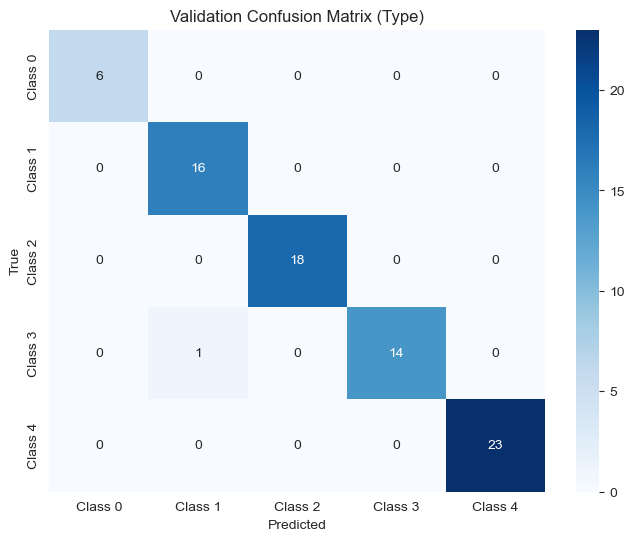

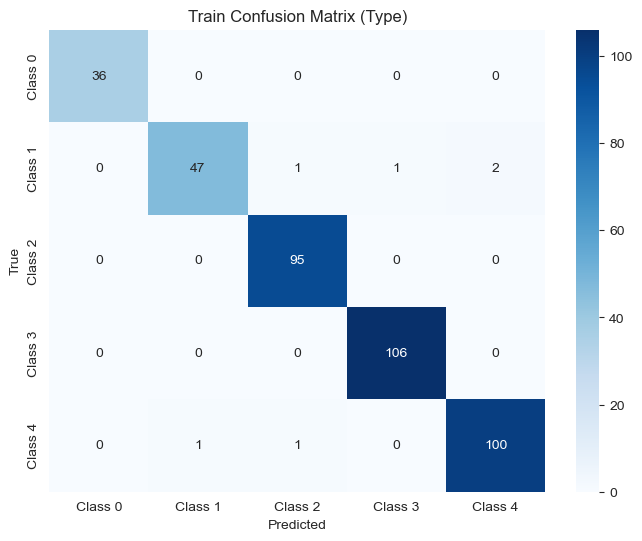

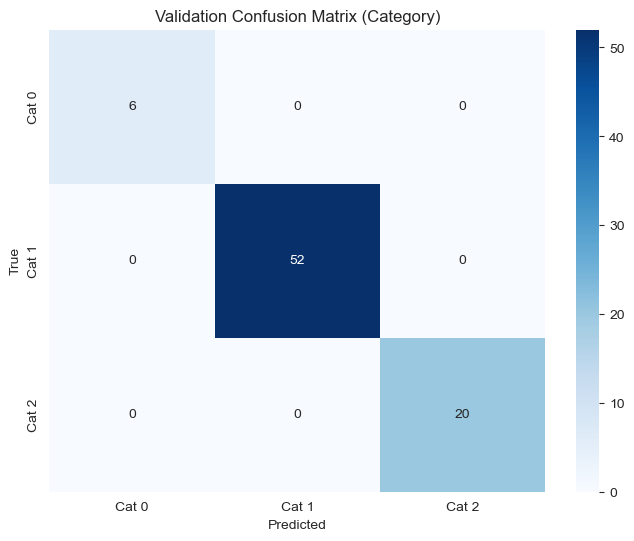

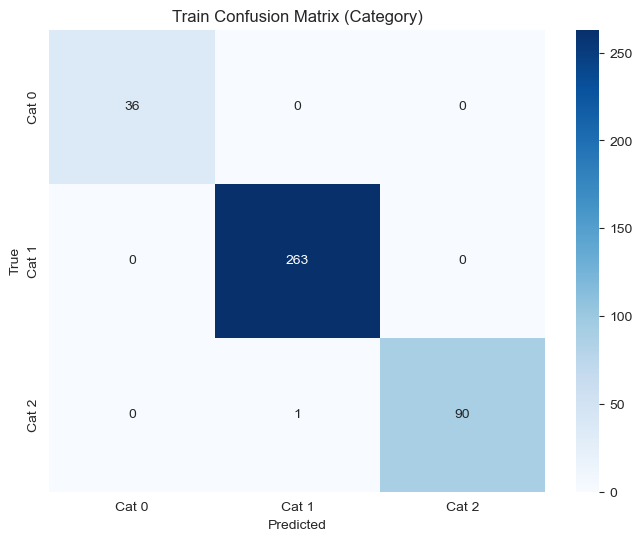

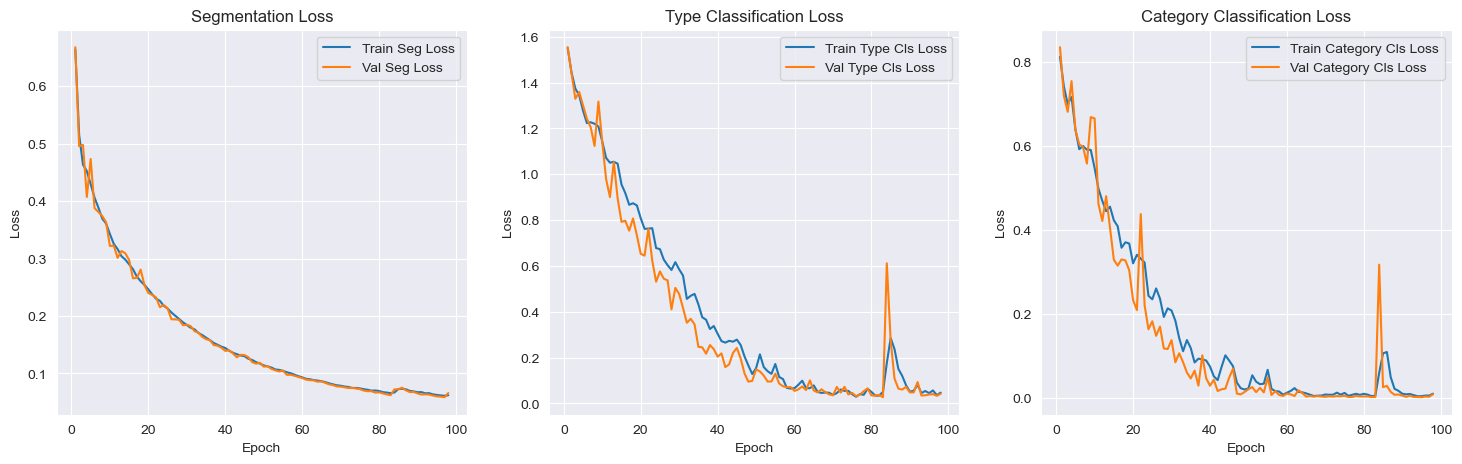

Train Dice: 0.9903 | Validation Dice: 0.9894


In [8]:
# --- تنظیم دستگاه ---
set_seed(42)  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- مدل ---
unet = AttentionUNetWithClassifier(in_channels=3, out_channels=1,
                                   num_type_classes=5,
                                   num_category_classes=3).to(device)

# --- Loss و Optimizer ---
criterion_seg = nn.BCEWithLogitsLoss()
criterion_cls_type = nn.CrossEntropyLoss()
criterion_cls_category = nn.CrossEntropyLoss()

optimizer_unet = torch.optim.Adam(unet.parameters(), lr=1e-4)

# --- تعداد Epoch ---
num_epochs = 200

# --- اجرا کردن Training ---
results = train_loop(
    unet, device, train_loader, val_loader,
    optimizer_unet,
    criterion_seg, criterion_cls_type, criterion_cls_category,
    epochs=num_epochs, patience=50
)

train_losses_seg = results["train_losses_seg"]
val_losses_seg = results["val_losses_seg"]
train_losses_cls_type = results["train_losses_cls_type"]
val_losses_cls_type = results["val_losses_cls_type"]
train_losses_cls_category = results["train_losses_cls_category"]
val_losses_cls_category = results["val_losses_cls_category"]
val_preds_cls_type = results["val_preds_cls_type"]
val_labels_cls_type = results["val_labels_cls_type"]
train_preds_cls_type = results["train_preds_cls_type"]
train_labels_cls_type = results["train_labels_cls_type"]
val_preds_cls_category = results["val_preds_cls_category"]
val_labels_cls_category = results["val_labels_cls_category"]
train_preds_cls_category = results["train_preds_cls_category"]
train_labels_cls_category = results["train_labels_cls_category"]
val_preds_seg = results["val_preds_seg"]
val_labels_seg = results["val_labels_seg"]
train_preds_seg = results["train_preds_seg"]
train_labels_seg = results["train_labels_seg"]

# --- اسم کلاس‌ها ---
class_names_type = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]
class_names_category = ["Cat 0", "Cat 1", "Cat 2"]

# --- Confusion Matrices ---
plot_confusion_matrix(val_preds_cls_type, val_labels_cls_type, class_names=class_names_type, dataset_type="Validation", title_suffix="(Type)")
plot_confusion_matrix(train_preds_cls_type, train_labels_cls_type, class_names=class_names_type, dataset_type="Train", title_suffix="(Type)")

plot_confusion_matrix(val_preds_cls_category, val_labels_cls_category, class_names=class_names_category, dataset_type="Validation", title_suffix="(Category)")
plot_confusion_matrix(train_preds_cls_category, train_labels_cls_category, class_names=class_names_category, dataset_type="Train", title_suffix="(Category)")

# --- Loss Plots ---
plot_losses(train_losses_seg, val_losses_seg,
            train_losses_cls_type, val_losses_cls_type,
            train_losses_cls_category, val_losses_cls_category)

# --- Dice و IoU نمونه ---
train_dice = dice_coefficient(train_preds_seg, train_labels_seg)
val_dice = dice_coefficient(val_preds_seg, val_labels_seg)
print(f"Train Dice: {train_dice:.4f} | Validation Dice: {val_dice:.4f}")
